**Mount Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Load Libraries**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

pd.set_option('display.max_columns', None)

print("Libraries imported successfully")

Libraries imported successfully


**Load Dataset**

In [3]:
columns = ['TweetID', 'Entity', 'Sentiment', 'Tweet']

train_df = pd.read_csv(
    '/content/drive/MyDrive/Twitter/twitter_training.csv',
    names=columns
)

val_df = pd.read_csv(
    '/content/drive/MyDrive/Twitter/twitter_validation.csv',
    names=columns
)

print("Training Dataset Shape:", train_df.shape)
print("Validation Dataset Shape:", val_df.shape)

Training Dataset Shape: (74682, 4)
Validation Dataset Shape: (1000, 4)


**Initial Data Inspection**

In [4]:
display(train_df.head())

print("\nTraining Dataset Info:")
print(train_df.info())

print("\nMissing Values:")
print(train_df.isnull().sum())

print("\nSentiment Distribution:")
print(train_df['Sentiment'].value_counts())

,TweetID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...



Training Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   TweetID    74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB
None

Missing Values:
TweetID        0
Entity         0
Sentiment      0
Tweet        686
dtype: int64

Sentiment Distribution:
Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


**Data Cleanup**

In [7]:
train_df.dropna(inplace=True)

print(train_df.shape)
val_df.dropna(inplace=True)

print(val_df.shape)
print(train_df.isnull().sum())
print(val_df.isnull().sum())

(73996, 4)
(1000, 4)
TweetID      0
Entity       0
Sentiment    0
Tweet        0
dtype: int64
TweetID      0
Entity       0
Sentiment    0
Tweet        0
dtype: int64


**Exploratory Data Analysis**

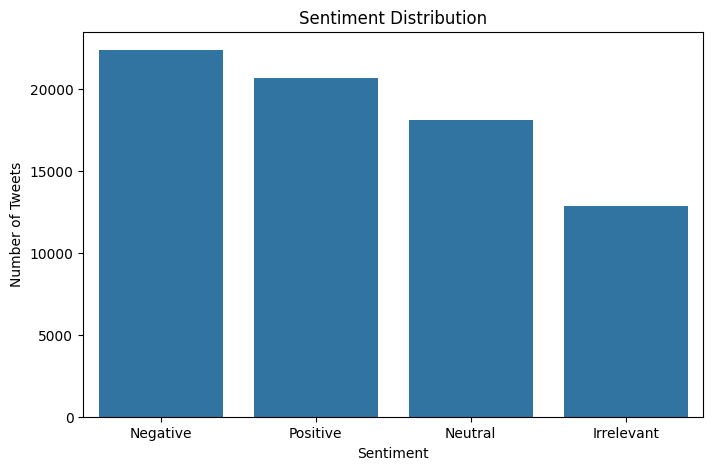

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Sentiment',
    data=train_df,
    order=train_df['Sentiment'].value_counts().index
)

plt.title('Sentiment Distribution')

plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')

plt.savefig(
    'fig1_sentiment_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

**Text Length Analysis**

                                               Tweet  Tweet_Length
0  im getting on borderlands and i will murder yo...            53
1  I am coming to the borders and I will kill you...            51
2  im getting on borderlands and i will kill you ...            50
3  im coming on borderlands and i will murder you...            51
4  im getting on borderlands 2 and i will murder ...            57


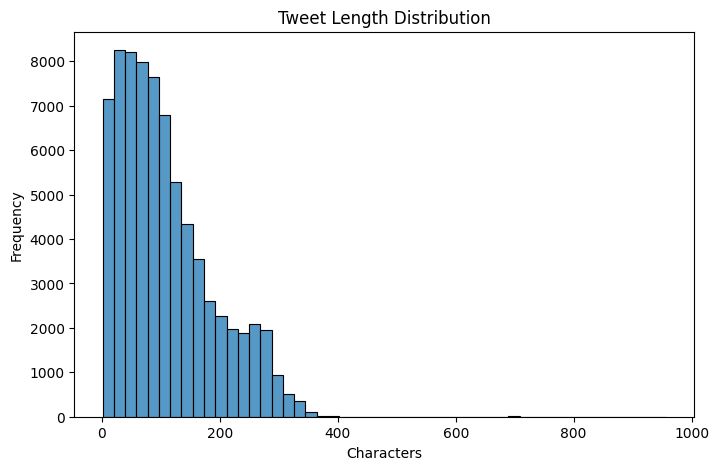

In [11]:
# Create tweet length column

train_df['Tweet_Length'] = train_df['Tweet'].astype(str).apply(len)

print(train_df[['Tweet', 'Tweet_Length']].head())
plt.figure(figsize=(8,5))

sns.histplot(
    train_df['Tweet_Length'],
    bins=50
)

plt.title('Tweet Length Distribution')
plt.xlabel('Characters')
plt.ylabel('Frequency')

plt.savefig(
    'fig2_tweet_length_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

**Average Tweet Length by Sentiment**

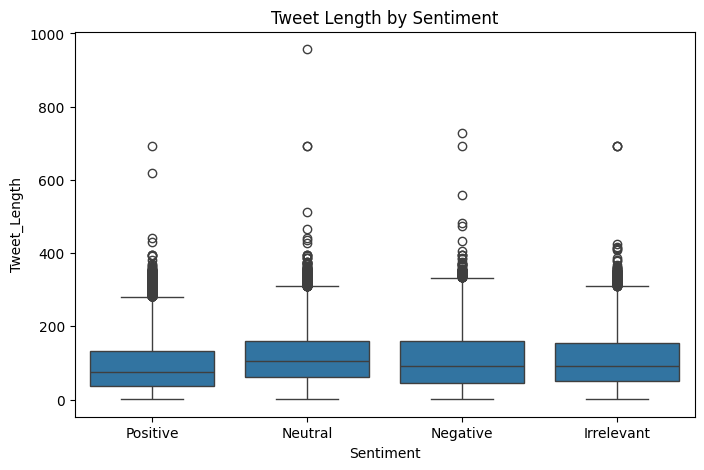

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Sentiment',
    y='Tweet_Length',
    data=train_df
)

plt.title('Tweet Length by Sentiment')

plt.savefig(
    'fig3_tweet_length_by_sentiment.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

**Text Pre processing**

Cleaning Function

In [13]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'www\S+', '', text)

    text = re.sub(r'@\w+', '', text)

    text = re.sub(r'#\w+', '', text)

    text = re.sub(r'\d+', '', text)

    text = text.translate(
        str.maketrans(
            '',
            '',
            string.punctuation
        )
    )

    text = re.sub(r'\s+', ' ', text).strip()

    return text

Apply Cleaning

In [14]:
train_df['Clean_Tweet'] = train_df['Tweet'].apply(clean_text)

val_df['Clean_Tweet'] = val_df['Tweet'].apply(clean_text)

Check Results

In [15]:
train_df[
    ['Tweet', 'Clean_Tweet']
].head()

,Tweet,Clean_Tweet
0,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...
1,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
3,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
4,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...


**TF-IDF Vectorization**

 Feature Extraction using TF-IDF

In [16]:
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words='english'
)

Fit on Training Data

In [17]:
X_train_tfidf = tfidf.fit_transform(
    train_df['Clean_Tweet']
)

Transform Validation Data

In [18]:
X_val_tfidf = tfidf.transform(
    val_df['Clean_Tweet']
)

Target Variables

In [19]:
y_train = train_df['Sentiment']

y_val = val_df['Sentiment']
print(X_train_tfidf.shape)

print(X_val_tfidf.shape)

(73996, 10000)
(1000, 10000)


**Logistic Regression Sentiment Classifier**

Train Model

In [20]:
lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

print("Logistic Regression Training Complete")

Logistic Regression Training Complete


Predictions & Accuracy

In [21]:
y_pred_lr = lr_model.predict(
    X_val_tfidf
)
print(
    "Accuracy:",
    accuracy_score(
        y_val,
        y_pred_lr
    )
)

Accuracy: 0.86


Classification Report & Confusion Matrix

              precision    recall  f1-score   support

  Irrelevant       0.83      0.80      0.81       172
    Negative       0.80      0.91      0.85       266
     Neutral       0.93      0.80      0.86       285
    Positive       0.88      0.91      0.90       277

    accuracy                           0.86      1000
   macro avg       0.86      0.85      0.86      1000
weighted avg       0.86      0.86      0.86      1000



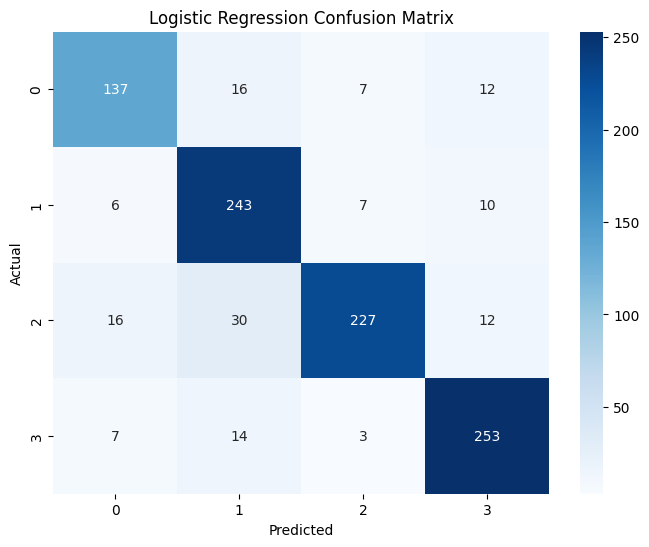

In [22]:
print(
    classification_report(
        y_val,
        y_pred_lr
    )
)
cm_lr = confusion_matrix(
    y_val,
    y_pred_lr
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Logistic Regression Confusion Matrix'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.savefig(
    'fig4_logistic_confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

**Naive Bayes Sentiment Classifier**

In [23]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

print("Naive Bayes Training Complete")

Naive Bayes Training Complete


Accuracy: 0.766
              precision    recall  f1-score   support

  Irrelevant       0.85      0.60      0.71       172
    Negative       0.69      0.88      0.77       266
     Neutral       0.87      0.65      0.74       285
    Positive       0.75      0.88      0.81       277

    accuracy                           0.77      1000
   macro avg       0.79      0.75      0.76      1000
weighted avg       0.78      0.77      0.76      1000



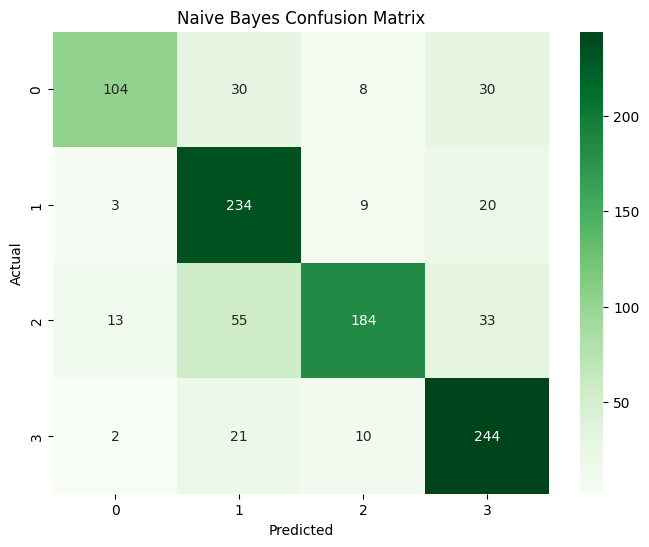

In [24]:
y_pred_nb = nb_model.predict(
    X_val_tfidf
)
print(
    "Accuracy:",
    accuracy_score(
        y_val,
        y_pred_nb
    )
)
print(
    classification_report(
        y_val,
        y_pred_nb
    )
)
cm_nb = confusion_matrix(
    y_val,
    y_pred_nb
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    'Naive Bayes Confusion Matrix'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.savefig(
    'fig5_naive_bayes_confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

**Top Terms by TF-IDF Frequency**

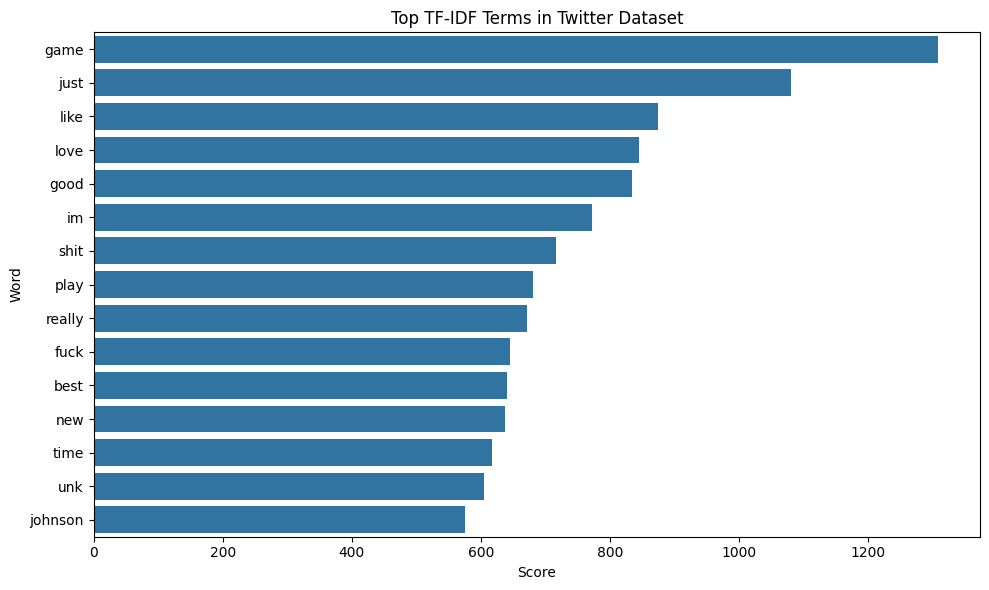

In [26]:
feature_names = tfidf.get_feature_names_out()

tfidf_scores = np.asarray(
    X_train_tfidf.sum(axis=0)
).flatten()

top_words = pd.DataFrame({
    'Word': feature_names,
    'Score': tfidf_scores
})

top_words = top_words.sort_values(
    by='Score',
    ascending=False
)

top_words.head(15)
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_words.head(15),
    x='Score',
    y='Word'
)

plt.title(
    'Top TF-IDF Terms in Twitter Dataset'
)

plt.tight_layout()

plt.savefig(
    'fig6_top_terms.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()